# Plotting Graphs
Visualizing Graphs can easily be automated using datastructures and methods from the `visualization` package.
This notebook shows some features and flows on how to display and format graphs.
Execute the cell below to read the example design and retrieve the circuit graph object for further customization.


In [ ]:
import netlist_carpentry

FILE_PATH = "../files/decentral_mux.v"
circuit = netlist_carpentry.read(FILE_PATH, top="decentral_mux")
circuit.top.optimize()
GRAPH = circuit.top.graph()

Within the `visualization` package, there is a class `Plotting`, which is intended to make visual depiction of graphs easier, providing a bunch of methods for customized graph representations.
When instantiating the `Plotting` class, it accepts
- a graph, which will be formatted,
- optionally a `Format` object (will be explained later),
- optionally a default node color,
- optionally a default node size.
Execute the cell below to create a basic, uncustomized plot from the graph first.

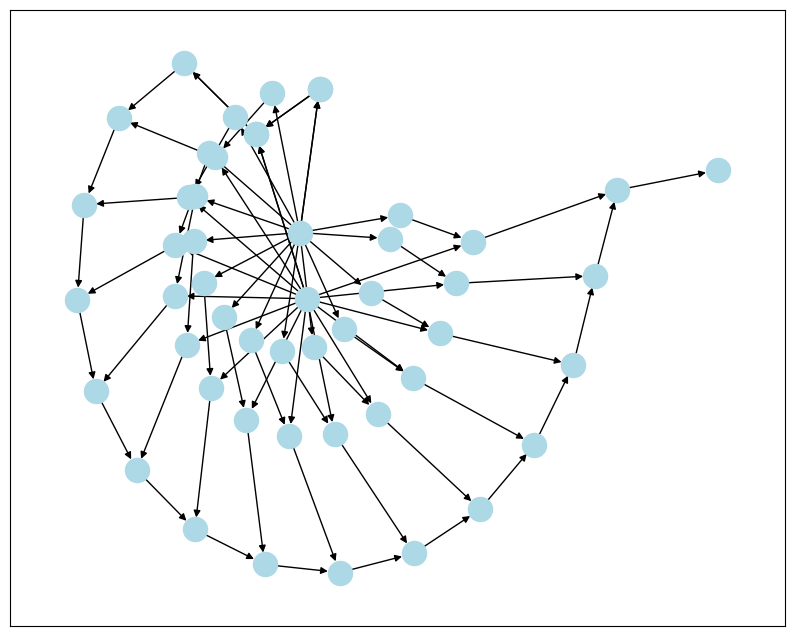

In [2]:
from netlist_carpentry.core.graph.visualization import Plotting

plot = Plotting(GRAPH)
plot.show()

Using `Plotting.set_labels_default`, each node receives a label.
For input or output port nodes, it is the name of the port.
For instances, it is the instance type by default.

<div class="admonition info alert alert-info">
  <strong>Info:</strong> <b>Plotting.set_labels_default</b> accepts a parameter <b>show_instance_names</b>, with which the plot will contain the instance names instead of the types (if the parameter is set to True).
  However, this may result in a very incomprehensible plot, as each primitive gate instance will receive a very generic name.
</div>

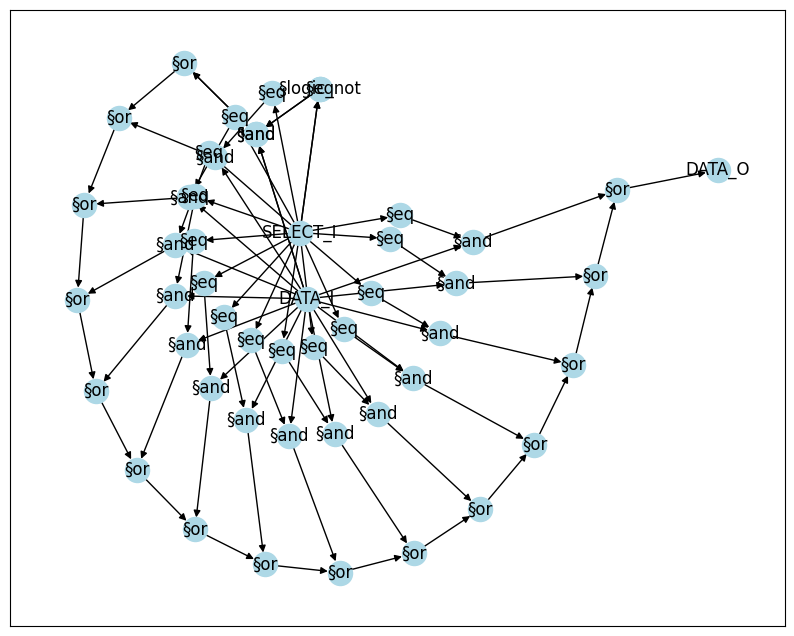

In [3]:
plot.set_labels_default()  # Alternative: plot.set_labels_default(show_instance_names=True)
plot.show()

The `Plotting` class supports creating and managing reusable formats (more on this in the dedicated notebook).
This all boils down to the `Plotting.set_format` and `Plotting.format_node` methods.
With `set_format(format_name, **format_parameters)`, a format template can be created or modified.
The `format_node(node_name, format_name)` method then applies the corresponding format template to the given node.
Execute the cell below to format a single node to a bright green color.

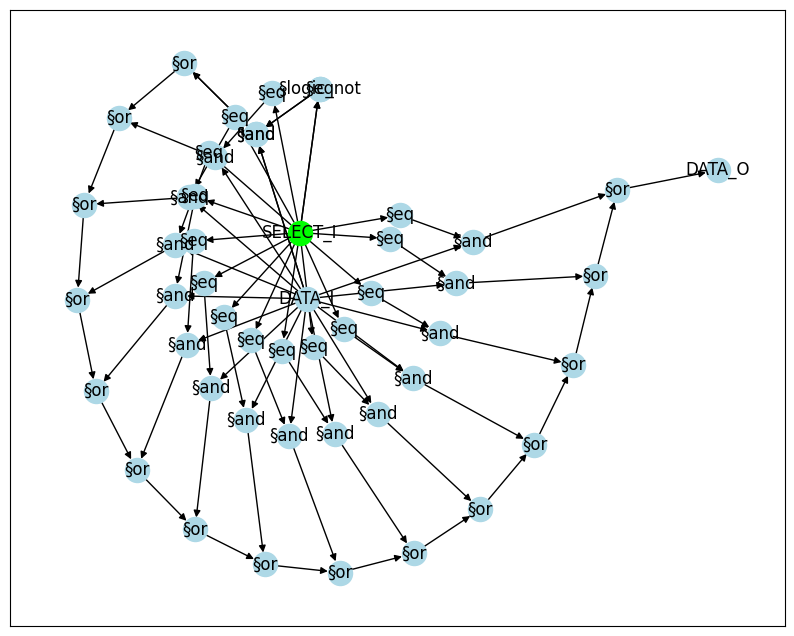

In [4]:
plot.set_format("green_format", node_color='#00FF00')
plot.format_node('SELECT_I', "green_format")
plot.show()

Using `Plotting.format_nodes`, nodes can be batch-formatted.
Like the `format_node` method, it takes a format name, but the first parameter is a predicate function (can be a lambda) that takes two parameters:
- the node name,
- the node data dictionary,
which can then be used to filter nodes according to their respective name or data.

Execute the cell below to color all nodes representing instances in cyan.

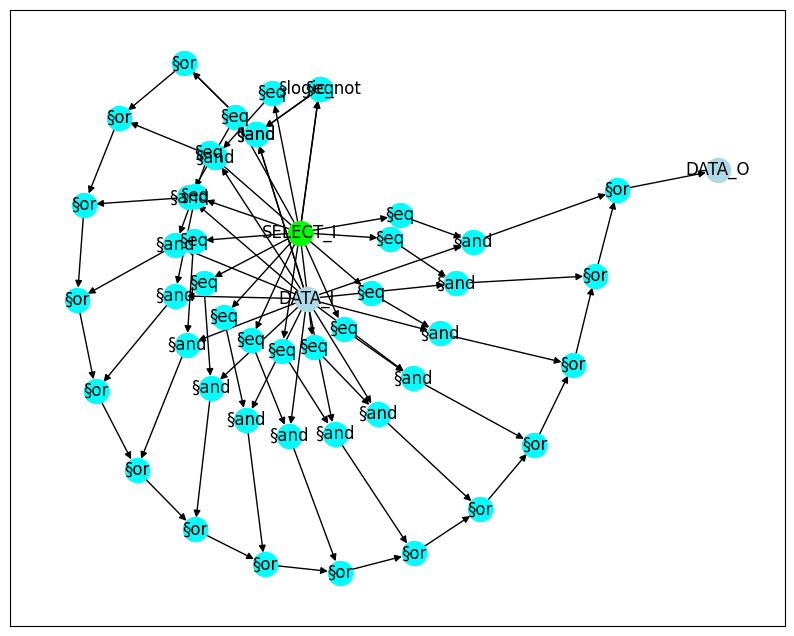

In [5]:
plot.set_format(name="cyan_format", node_color="cyan")
plot.format_nodes(lambda node_name, node_data: node_data["ntype"] == "INSTANCE", format_name="cyan_format")
plot.show()

Nodes can also be of different sizes, also applicable via the `set_format` method.
Execute the cell below to enlargen all nodes representing OR gate instances and make them orange as well.

<div class="admonition info alert alert-info">
  <strong>Info:</strong> Notice how previous formatting is overwritten, making the previously cyan nodes now orange.
</div>

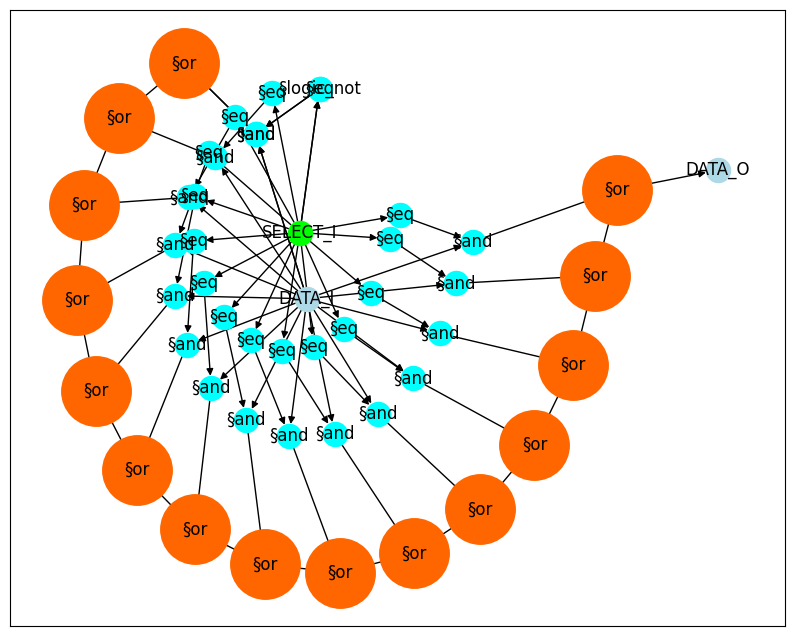

In [6]:
plot.set_format("large_nodes", node_color="#FF6600", node_size=2500)
plot.format_nodes(lambda node_name, data: data.get("nsubtype") == "§or", format_name="large_nodes")
plot.show()

In an alternative case, all nodes with similar names could possibly be highlighted.
This is also possible via the lambda function, now utilizing the node name instead of the node data.
Execute the cell below to color all nodes with `data` (case-insensitive) in their names in dark blue.

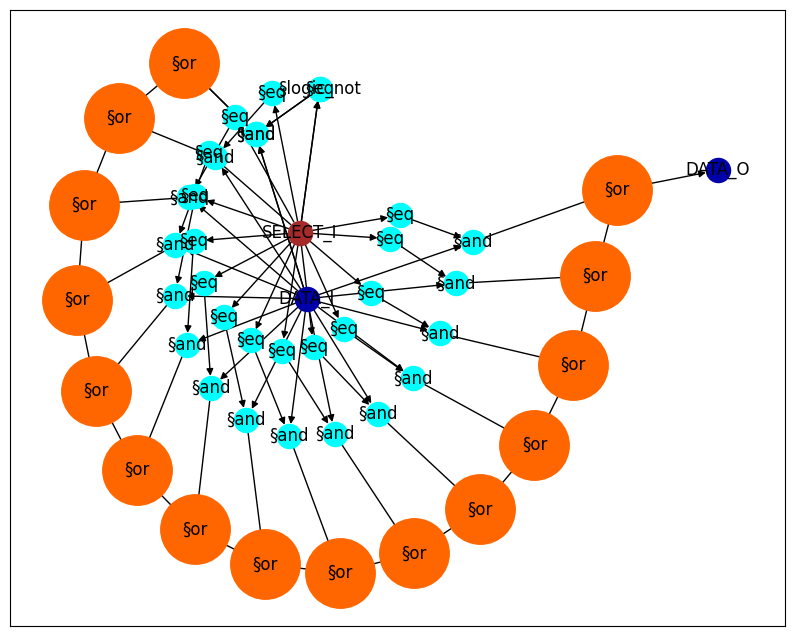

In [9]:
plot.set_format("dark_blue", node_color="#0000AA")
plot.format_nodes(lambda node_name, data: "data" in node_name.lower(), format_name="dark_blue")
plot.show()

Another useful function is `Plotting.format_in_out` which formats all inputs and outputs according to the given format names.
Execute the cell below, to recreate a similar image to the one above, but with different coloring for the input and output port nodes.

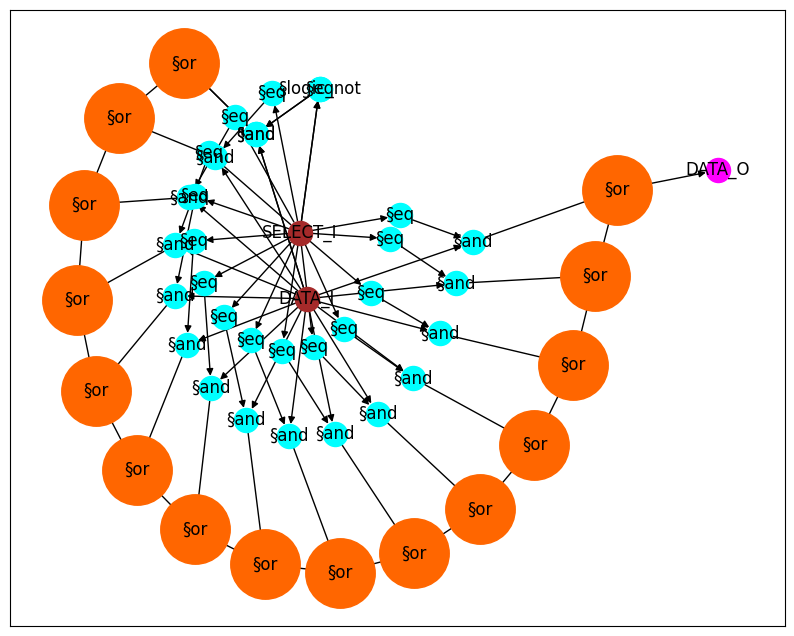

In [8]:
plot.set_format(name="brown_format", node_color="brown")
plot.set_format(name="magenta_format", node_color="magenta")
plot.format_in_out(in_format="brown_format", out_format="magenta_format")
plot.show()